# 预处理

In [ ]:
# 本文件《01_embedding_padding_pooling.ipynb》主要演示了文本数据在深度学习中的预处理流程，涵盖了Embedding（词嵌入）、Padding（序列补齐）、Pooling（池化/降维处理）等关键技术环节。
# 文件主体内容围绕Keras自带的IMDB电影评论分类数据集展开，内容包括：
# 1. 数据集的加载与基础探索（包括词汇表、样本与标签的结构与含义）；
# 2. 词表构建与索引映射原理，如何将文本转为数字序列，处理特殊token如PAD、BOS、UNK等；
# 3. 利用Keras和TensorFlow等工具，对变长的文本序列做统一长度的Padding补齐处理；
# 4. Embedding层原理与使用方法，将稀疏的数字序列转为稠密向量表征（词向量）；
# 5. 池化技术（如GlobalAveragePooling/MaxPooling），用于文本序列向量的降维与特征整合，为下游分类等任务做准备；
# 6. 通过可视化和示例代码，帮助理解各步骤的处理效果和变换过程。
# 本文件既适合作为深度学习文本预处理的教学案例，也可作Keras文本分类任务的入门参考。

import os
# 这是导入Keras中IMDB影评数据集的模块
from tensorflow.keras.datasets import imdb

# 数据默认下载路径在 C:\Users\41507\.keras\datasets
# Keras 会自动将 IMDB 数据集下载到该目录。如果已经下载过，就会直接加载本地的数据。

# 指定词汇表大小，只保留最常见的前10000个单词（其余的单词都会被视为OOV/未知词）
num_words = 10000

# 加载IMDB电影评论数据集
# imdb.load_data参数说明：
#   num_words: 保留词频排名前num_words的单词(其余的单词都用"UNK"表示，索引2)
#   index_from: 实际的单词索引需要加上该数值（为留出一些索引给特殊符号）
#   返回值为((x_train, y_train), (x_test, y_test)):
#       x_train, x_test: 训练和测试集的评论，已编码为word_index映射的整数序列
#       y_train, y_test: 对应的标签，二分类(0/1)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words, index_from=3)

# 打印训练数据的类型和形状
print(type(x_train))      # <class 'numpy.ndarray'>, 其中每个元素其实是一个list（样本长度不一）
print(x_train.shape)      # (25000,)
print(x_test.shape)       # (25000,)
# print(type(x_train[0]))

# 查看第一个训练样本的编码，以及前10个标签
print("第一个训练样本：", x_train[0])  # 显示第一个评论被编码的整数列表
print("标签：", y_train[0:10])       # 显示前10个训练样本的标签(0负/1正)


# 加载IMDB的word_index词典。原始的word_index是{word: index}的映射，index从1开始。
# 这是把IMDB原始的word_index词典（单词到编号的映射）加载出来，后续用于将数字序列解码回原始单词。


word_index = imdb.get_word_index()
# print(type(word_index))

# imdb的原始词典中，index是从1开始的。Keras使用以下约定保留了0、1、2索引用于特殊用途：
#   0 -> [PAD]（用于序列补齐）
#   1 -> [BOS]（句首标志）
#   2 -> [UNK]（未登录词）
# 此外，index_from=3意味着真正的单词索引都需要+3，前面留出0,1,2,3这几个编号

word_index = {word: idx + 3 for word, idx in word_index.items()}  # 每个词的索引都+3，留出0,1,2,3

# print(word_index)
# 添加特殊token到词典中，对应的索引
word_index.update({
    "[PAD]": 0,  # 填充token，序列补齐用
    "[BOS]": 1,  # 句子开头
    "[UNK]": 2,  # 未知词
    "[EOS]": 3,  # 句子结尾（虽然IMDB默认没有使用）
})

# 打印第二个训练样本的编码结果，观察原始的数字表示
print(x_train[1])


<class 'numpy.ndarray'>
(25000,)
(25000,)
第一个训练样本： [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
标签： [1 0 

In [3]:
word_index['hi']

6596

In [4]:
# 构建索引到词的词典（将 word->idx 反转为 idx->word 的映射）
# 这样方便通过词索引找到原始的单词，实现数字序列到句子的转换
index_to_word = {idx: word for word, idx in word_index.items()}
print(type(index_to_word[0]))

# 编写decode_review函数，用于将编码后的评论（数字索引序列）解码为可读文本
def decode_review(encoded_review):
    # 对于评论中的每一个单词索引idx，从index_to_word中查找对应单词
    # 如果找不到（可能出现未知索引），则用'?'代替
    # 最后将单词列表用空格拼接成完整句子
    return ' '.join([index_to_word.get(idx, '?') for idx in encoded_review])

# 测试decode_review函数，显示第一个训练样本的原始文本内容
print("解码后的第一个训练样本：")
print(decode_review(x_train[0]))


<class 'str'>
解码后的第一个训练样本：
[BOS] this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert [UNK] is an amazing actor and now the same being director [UNK] father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for [UNK] and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also [UNK] to the two little boy's that played the [UNK] of norman and paul they were just brilliant children are often left out of the [UNK] list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and 

In [5]:
import numpy as np

# ========================== 数据保存与读取示例 ============================
# 本段代码演示如何将Numpy中的ndarray（如训练/测试数据）保存到磁盘
# 以及如何从磁盘加载这些数据回来。这样可以避免重复处理原始数据，
# 大幅加快调试和实验过程，尤其是在数据预处理步骤较为耗时时。

# ---- 保存ndarray到磁盘 ----
# 使用np.save(filename, array, allow_pickle=True) 可以把任意numpy数组保存为二进制文件(.npy格式)
# 解释：allow_pickle=True 表示在保存(np.save)或读取(np.load)Numpy数组时，允许序列化（pickling）Python对象。
# 这一参数常用于保存包含不规则对象（如列表嵌套、变长序列等）的ndarray，
# 否则如果你的ndarray中每个元素是个list/对象而不是纯数值矩阵，不加allow_pickle=True会报错！

# 举例说明：
# arr = np.array([[1, 2, 3], [4, 5]], dtype=object)
# np.save("tmp.npy", arr, allow_pickle=True)  # 正常保存
# arr_loaded = np.load("tmp.npy", allow_pickle=True) # 正常读取

# 其中 allow_pickle=True 使得可以保存对象dtype的ndarray（如存放不同长度的序列）

# 示例：依次保存训练和测试数据（解注释后可实际运行，前提是x_train等变量已准备好）
np.save('x_train.npy', x_train, allow_pickle=True)  # 保存训练输入
np.save('y_train.npy', y_train, allow_pickle=True)  # 保存训练标签
np.save('x_test.npy', x_test, allow_pickle=True)    # 保存测试输入
np.save('y_test.npy', y_test, allow_pickle=True)    # 保存测试标签

# ---- 从磁盘加载ndarray文件 ----
# 使用np.load(filename, allow_pickle=True) 加载保存的数据
# 加载时需指定allow_pickle=True，尤其当内容为嵌套列表或变长数据时

# 示例：按顺序加载之前保存的训练和测试数据
x_train_loaded = np.load('x_train.npy', allow_pickle=True)  # 读取训练输入
y_train_loaded = np.load('y_train.npy', allow_pickle=True)  # 读取训练标签
x_test_loaded = np.load('x_test.npy', allow_pickle=True)    # 读取测试输入
y_test_loaded = np.load('y_test.npy', allow_pickle=True)    # 读取测试标签

# 检查加载后的数据形状，确认是否一致（实际开发建议加此检查）
print('x_train_loaded shape:', x_train_loaded.shape)
print('y_train_loaded shape:', y_train_loaded.shape)
print('x_test_loaded shape:', x_test_loaded.shape)
print('y_test_loaded shape:', y_test_loaded.shape)

# ========================================================================


x_train_loaded shape: (25000,)
y_train_loaded shape: (25000,)
x_test_loaded shape: (25000,)
y_test_loaded shape: (25000,)


In [6]:
# 将测试集划分为验证集和测试集
# 从原始测试集中取前10000个样本作为验证集
x_val = x_test[:10000]
y_val = y_test[:10000]

# 剩余的15000个样本作为测试集
x_test = x_test[10000:]
y_test = y_test[10000:]

print(f"验证集样本数: {len(x_val)}")
print(f"测试集样本数: {len(x_test)}")
print(f"验证集标签示例: {y_val[:10]}")
print(f"测试集标签示例: {y_test[:10]}")

验证集样本数: 10000
测试集样本数: 15000
验证集标签示例: [0 1 1 0 1 1 1 0 0 1]
测试集标签示例: [1 1 0 1 0 0 1 0 1 1]


## 通过直方图来观察样本长度分布

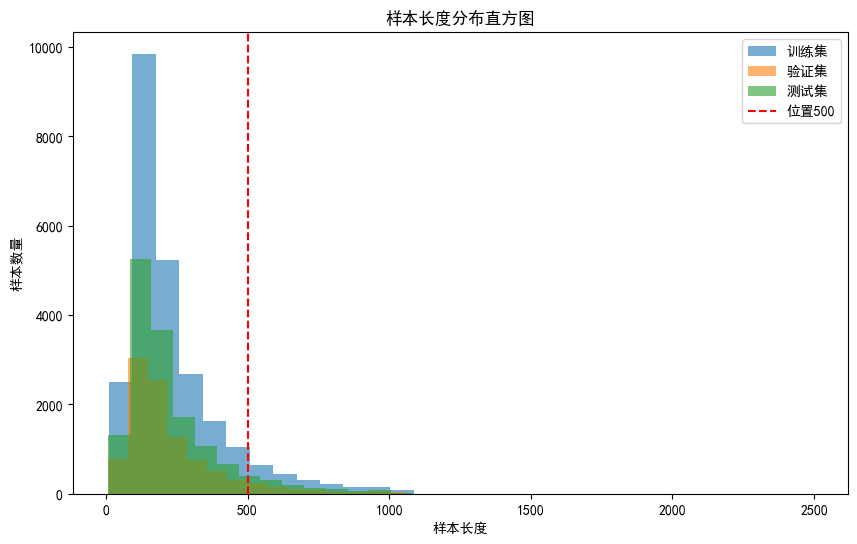

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

# 配置Matplotlib以正常显示中文标签和负号
matplotlib.rcParams['font.sans-serif'] = ['SimHei']         # 设置中文字体为黑体，用于在图形中正确显示中文
matplotlib.rcParams['axes.unicode_minus'] = False           # 正常显示坐标轴中的负号，不会变成乱码

# 这里的长度是单词数（即每个样本中的token/单词的数量），不是字母数。

# 分别统计训练集、验证集和测试集中每个样本（序列）的长度
# x_train、x_val、x_test均为样本集合，每个元素为一个序列（如token id列表）
train_lengths = [len(seq) for seq in x_train]               # 列表推导式计算训练集每个样本的长度
val_lengths = [len(seq) for seq in x_val]                   # 计算验证集每个样本的长度
test_lengths = [len(seq) for seq in x_test]                 # 计算测试集每个样本的长度

# 创建图形窗口，设置大小为10x6英寸
plt.figure(figsize=(10, 6))

# 绘制训练集样本长度的直方图
# 参数解释:
# plt.hist() 函数用于绘制直方图。
#   - 第一个参数(train_lengths, val_lengths, test_lengths)为数据列表，表示不同集合中每个样本的序列长度。
#   - bins=30 设定直方图的箱子数，也就是将数据分成多少段统计。
#   - alpha=0.6 设置颜色透明度（1为不透明，0为完全透明），方便多组数据同时展示时不完全遮盖。
#   - label 用于在图例中显示该数据系列的标签。
# plt.axvline() 用于在图形上绘制竖直的参考线。
#   - x=500 表示竖线的横坐标。
#   - color='r' 设置颜色为红色。
#   - linestyle='--' 虚线。
#   - label 图例标记。
# plt.xlabel()/plt.ylabel() 设置横纵轴的名称。
# plt.title() 设置图表标题。
# plt.legend() 显示图例，便于辨认不同的数据系列。
# plt.show() 展示绘制出的图形窗口。

plt.hist(train_lengths, bins=30, alpha=0.6, label='训练集')
# 绘制验证集样本长度的直方图
plt.hist(val_lengths, bins=30, alpha=0.6, label='验证集')
# 绘制测试集样本长度的直方图
plt.hist(test_lengths, bins=30, alpha=0.6, label='测试集')

# 在x=500的位置画一条红色虚线，用于参考，label设置为“位置500”
plt.axvline(x=500, color='r', linestyle='--', label='位置500')

# 设置x轴为“样本长度”，y轴为“样本数量”
plt.xlabel('样本长度')
plt.ylabel('样本数量')

# 设置图形标题
plt.title('样本长度分布直方图')

# 显示图例（根据label参数自动显示不同集合的颜色标记）
plt.legend()

# 渲染显示图形
plt.show()


# Tokenizer

In [ ]:
from unittest import result
import numpy as np  # 确保np被导入

# 在上面 Tokenizer 已经实现了文本到id的编码（encode）和id到文本的解码（decode），这里再强调一下原因：
# 1. 教学目的：帮助理解分词、编码、解码的流程，以及如何实现可扩展的Tokenizer类。
# 2. 有时不同项目/需求下 encode/decode 的实现方式可能需要自定义，比如添加特殊符号或支持不同的填充、截断方式。
# 3. 为后续演示 embedding/序列模型等任务做通用接口和软件设计铺垫，使代码结构清晰可维护。
# 因此不但要会用已有方法，还要知道如何自己实现底层逻辑，这对于深刻理解文本建模非常重要。


# Tokenizer的作用与用法总结
# 
# 作用：
# Tokenizer用于将文本序列（字符串列表）转为整数ID序列，便于神经网络模型处理，并可实现分词、填充（pad）、截断、编码（encode）、解码（decode）等功能，是NLP文本预处理的基础工具。
#
# 用法举例：
# 假设vocab = {"[PAD]":0, "[BOS]":1, "[UNK]":2, "[EOS]":3, "hello":4, "world":5}
# tokenizer = Tokenizer(word_index=vocab, index_to_word={v:k for k,v in vocab.items()})
#
# # 例如编码（转为id序列，自动补pad或加特殊符号）:
# data = [["hello", "world"], ["hello"]]
# ids = tokenizer.encode(data, maxlen=5, padding='post', add_bos=True, add_eos=True)
#
# # 解码：将id序列转回文本
# text = tokenizer.decode(ids)
#
# # 支持批量输入，每个序列可按需补pad/截断定长以及添加BOS/EOS等特殊token。

class Tokenizer:
    def __init__(self, word_index, index_to_word):
        """
        构造函数，初始化Tokenizer对象。

        参数说明:
            word_index: dict类型，单词到索引的映射（如{"hello":5, ...}），用于将单词转换成对应的整数ID，便于后续神经网络处理。
            index_to_word: dict类型，索引到单词的映射（如{5:"hello", ...}），用于解码，将ID逆向还原成单词文本。
        """
        self.word_index = word_index                              # 保存单词->id映射表
        self.index_to_word = index_to_word                        # 保存id->单词映射表
        self.vocab_size = len(word_index)                         # 词表大小=字典大小

        # 这里 self.word_index 和 self.index_to_word 的 key 都是str类型。
        # text参数通常应为List[List[str]]，即分好词后的字符串二维列表。
        # 定义并存储特殊token及其id，便于后续填充/处理特殊符号
        self.pad_token = "[PAD]"                                  # 填充token名：用于补齐到统一长度
        self.bos_token = "[BOS]"                                  # 句首token名（Begin Of Sequence）
        self.unk_token = "[UNK]"                                  # 未知token名（词表外OOV词）
        self.eos_token = "[EOS]"                                  # 句尾token名（End Of Sequence）
        self.pad_id = self.word_index[self.pad_token]             # 填充token的id
        self.bos_id = self.word_index[self.bos_token]             # 句首token的id
        self.unk_id = self.word_index[self.unk_token]             # 未知token的id
        self.eos_id = self.word_index[self.eos_token]             # 句尾token的id

    def encode(self, text, maxlen=None, padding='post', truncating='post',
               add_bos=False, add_eos=False):
        """
        将批量经过分词的文本（list of list of string）编码为索引id组成的定长二维整型数组。
        支持前/后填充与截断, 以及选加BOS/EOS符号。

        参数说明:
            text: List[List[str]]，批量文本（如: [["hello", "world"], ...]），每个样本已分好词
            maxlen: int 或 None，指定输出序列的最大长度，None时根据当前批次自动调整
            padding: 填充方式，'pre'是在前面补pad, 'post'是后补pad。
            truncating: 截断方式，'pre'表示只保留最后maxlen个，'post'表示只保留最前maxlen个。
            add_bos: bool，是否在每个序列头部添加[BOS]标记的id
            add_eos: bool，是否在每个序列尾部添加[EOS]标记的id

        返回值:
            np.ndarray，形状(batch, maxlen)，其中每行都是经过pad/truncate调整后的整数id序列
        """
        # 校验输入类型，必须是二维list
        if not isinstance(text, list):
            raise ValueError("输入text应为字符串列表（List[List[str]]）")
        
        # 计算当前批次样本的最大原始长度
        batch_max_len = max([len(seq) for seq in text])   # 如果text每行为分词list, 求最大长度
        # 若指定加BOS/EOS符号，则1条序列长度+1
        if add_bos:
            batch_max_len += 1
        if add_eos:
            batch_max_len += 1

        # 若maxlen没指定，或者当前批次最大长度小于maxlen，则maxlen按最大样本序列长度决定
        if maxlen is None or batch_max_len < maxlen:
            maxlen = batch_max_len

        result = []  # 存储所有编码好pad好的序列
        for sample in text:  # 遍历每条分好词的样本
            sequence = []

            # 按需在序列起始添加BOS符号的id
            if add_bos:
                sequence.append(self.bos_id)

            # 遍历样本的每个单词，转成对应的id，若没有的单词统一为unk_id
            for word in sample:
                sequence.append(self.word_index.get(word, self.unk_id))

            # 按需在结尾添加EOS符号的id
            if add_eos:
                sequence.append(self.eos_id)

            # 若长度超限, 则截断
            # 详细解释:
            # 经过上面词转id、可能加了BOS/EOS后，sequence是整数id组成的序列。
            # 这里需要判断是否超出maxlen，如果超出就要按照truncating参数进行截断。
            # 'pre'表示截掉前面的token，只保留结尾部分；
            # 'post'（默认）表示截掉后面的token，只保留前面的maxlen个。
            # 具体代码会在后面对sequence作切片操作以实现截断。
            if len(sequence) > maxlen:
                if truncating == 'pre':        # 截断序列前面的部分
                    # 这里的 sequence[-maxlen:] 是 Python 的切片语法。
                    # 意思是“从 sequence 的倒数第 maxlen 个元素开始，取到最后一个元素”。
                    # 这样可以保留序列后面的 maxlen 个元素，实现从前面截断（丢弃前面的 token）。
                    # 例如：sequence = [1,2,3,4,5], maxlen=3，则 sequence[-3:] 结果为 [3,4,5]
                    sequence = sequence[-maxlen:]
                else:                          # 'post'默认，从头到maxlen
                    sequence = sequence[:maxlen]
            else:
                # 长度不足则补pad，对应填充pad_id
                pad_length = maxlen - len(sequence)
                if pad_length > 0:
                    if padding == 'pre':       # 在序列前补pad
                        sequence = [self.pad_id] * pad_length + sequence
                    else:                      # 默认：在序列后补pad
                        sequence = sequence + [self.pad_id] * pad_length

            # 处理好后保存到结果列表
            result.append(sequence)

        # 转为numpy二维数组，方便后续处理（如模型输入）
        return np.array(result)

    def decode(self, ids, remove_special=True):
        """
        批量将索引id序列还原成自然语言文本，每条输出为字符串（token间用空格隔开）。
        可选择是否移除特殊token，便于实际文本展示。

        参数说明:
            ids: List[List[int]] 或 np.ndarray，批量id序列（每行为1条样本的token id组成的序列）
            remove_special: bool，是否移除pad_token/bos_token/eos_token这些特殊标记

        返回值:
            List[str]，每个元素为还原后的句子字符串
        """
        results = []  # 用于存储还原后的文本序列
        # 构建特殊标记集合，后面判定是否跳过
        special_tokens = {self.pad_token, self.bos_token, self.eos_token}
        for seq in ids:                     # 遍历每一个样本（id序列）
            tokens = []                     # 用于保存当前样本还原出的token文本
            for idx in seq:                 # 遍历当前序列每个token的id
                # 根据id查找token字符串, 若没查到用unk_token
                token = self.index_to_word.get(idx, self.unk_token)
                # 如果选择去除特殊符号且当前token就是特殊符号，则跳过
                if remove_special and token in special_tokens:
                    continue
                tokens.append(token)        # 收集还原结果
            # 当前样本所有token，空格拼接成1条句子
            results.append(' '.join(tokens))
        return results


In [10]:
raw_text = ["hello world".split(), "tokenize text datas with batch".split(), "this is a test".split()]
raw_text

[['hello', 'world'],
 ['tokenize', 'text', 'datas', 'with', 'batch'],
 ['this', 'is', 'a', 'test']]

In [11]:
index_to_word[4825]

'hello'

In [12]:
tokenizer=Tokenizer(word_index,index_to_word)
encoded_text = tokenizer.encode(raw_text)
print(encoded_text)
decoded_text = tokenizer.decode(encoded_text)
print(decoded_text)


[[ 4825   182     0     0     0]
 [    2  3004     2    19 19233]
 [   14     9     6  2181     0]]
['hello world', '[UNK] text [UNK] with batch', 'this is a test']


# Dataset和DataLoader

In [13]:
a,b=zip(('a',1),('b',1),('c',0))
print(a)
print(b)


('a', 'b', 'c')
(1, 1, 0)


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

"""
整个流程围绕着“原始文本/token列表”和“token id序列”之间的相互转化，主要步骤和目的如下：

1. 原始数据通常是自然语言文本（如"hello world"），最初以字符串或分词后token列表的形式出现。
2. 在深度学习模型中，文本不能直接输入网络，要将每个token映射为整数id（即“编码”）。这通常通过Tokenizer/词表的encode方法实现，将文本转为token id序列。
3. 为了进行批训练（batch training），不同长度的句子需要统一长度——短的加padding，长的截断，这一步也在encode时完成。
4. DataLoader的数据采样有时会得到id序列（数字），但为方便调试或后续某些需要展示原文的环节，往往再将id序列"解码"回原文token（decode）。
5. Dataset/Loader部分之所以先decode回token再按collate_fn再encode，是因为实际数据常以字符串或token形式存在，collate_fn需要以统一的格式再批量编码和处理。
6. 这种编码—解码—再编码的流程，主要是为了灵活性和兼容性：方便兼容原始数据的各种存储（字符串、token列表、id）、在管道不同阶段都能看到/操作到人类可读的文本。

总结：
- 训练时，最终输入模型是padding好的id序列（tensor）
- 但管道中的不同环节，可能需要人类可读文本，也可能需要id序列，所以不断切换
- decode可以做调试/结果展示，encode是为模型做输入格式准备

简流程图：
原始文本 -> tokenize -> encode为id序列（可pad到定长）-> 模型
             ↑                                     ↓
        decode（方便展示/分析/调试，通常不是必须）
"""


class TextDataset(Dataset):
    def __init__(self, texts, labels):
        """
        文本数据集，继承自torch的Dataset类。
        参数:
            texts: 原始文本数据，列表形式。每个元素是一个句子的token id列表（或token序列）。
            labels: 标签数据，列表形式。每个元素是文本对应的标签。
        """

        # 对输入的token id序列进行解码，将其还原为token字符串再存储
        self.texts = tokenizer.decode(texts)
        self.labels = labels
    
    def __len__(self):
        """
        返回数据集的长度（样本数），便于DataLoader迭代获取批次。
        """
        return len(self.texts)
    
    def __getitem__(self, idx):
        """
        支持通过索引形式获取数据样本。
        返回指定索引的文本和标签
        """
        return self.texts[idx], self.labels[idx]

# 这是自定义文本数据集类TextDataset的定义，用于将原始的文本和标签封装成PyTorch可以使用的数据集对象（Dataset）。
# 结合自定义的collate_fn函数，可以用于批量处理文本数据，包括数据的编码、填充、截断等，方便后续用DataLoader进行模型训练和验证。

"""
答：是的，DataLoader会在每次产生一个batch时自动调用collate_fn进行处理。

具体流程：
- DataLoader每次从Dataset中取出batch_size个样本，组成一个batch（本质是一个样本列表）。
- 然后，DataLoader会将这个batch传给collate_fn，把这个“原始样本批”（如字符串或token序列）批量转换成适合模型输入的张量（如padding后的id序列，标签等）。
- 也就是说，每产生一次batch，就调用一次collate_fn，会对每个batch都执行一次你自定义的处理逻辑。
- 这一步是自动完成的，只要DataLoader指定collate_fn参数即可。

因此，你看到的模型每次训练/验证迭代里输入的batch，都是经过collate_fn处理、格式化好的。

"""

def collate_fn(batch, max_len=500):
    """
    自定义DataLoader的collate_fn，实现批量样本的编码和填充，以适应模型输入格式。
    参数:
        batch: 一个批次的样本数据。每个元素是(text, label)
        max_len: 序列填充的最大长度。超过此长度则截断，不足则填充padding。
    返回:
        编码后的样本batch：   shape = (batch_size, max_len)，类型为LongTensor
        标签batch：         shape = (batch_size, )，类型为LongTensor
    """
    
    # 这是Python中的参数解包与zip的结合用法，将batch列表中的每个元素（元组）进行“分组解压”
    # 假设 batch = [(a1, b1), (a2, b2), (a3, b3)]
    # zip(*batch) 相当于 zip((a1, b1), (a2, b2), (a3, b3))，生成 (a1, a2, a3), (b1, b2, b3)
    # 这样分别拿到所有文本(texts)和所有标签(labels)的列表
    texts, labels = zip(*batch)
    # 将每个text字符串按空格拆分为token列表，便于后续编码
    token_lists = [text.split() for text in texts]
    # 使用tokenizer将token列表批量编码为整数id序列，并统一长度（填充/截断）
    encoded_batch = tokenizer.encode(token_lists, maxlen=max_len)
    # 转为torch张量
    # 为什么要转换成tensor？
    # 因为PyTorch模型的输入要求是torch.tensor类型，只有这样才能进行自动求梯度、在GPU/CPU上运算，以及与模型参数统一类型。
    #
    # 原来是什么类型？
    # encoded_batch 在这里是一个普通的嵌套Python list（list of lists）；labels 也是Python的数字/整数list。
    # 这两者本身只是内存中的原生数据结构，不能直接用于PyTorch计算。
    #
    # 为什么不转换成ndarray等类型呢？
    # numpy.ndarray是numpy库的数据类型，虽然可以用来做数值计算，但不能支持PyTorch的自动求导、设备转移（.cuda()/.to(device)）等功能。
    # 而且，DataLoader和模型训练流程都假定数据是torch.tensor类型。因此需要在这里将它们转换为tensor。
    return torch.tensor(encoded_batch, dtype=torch.long), torch.tensor(labels, dtype=torch.long)

# ================== 以下为DataLoader创建及调试示例 ==================

# 创建训练集Dataset和DataLoader
train_dataset = TextDataset(x_train, y_train)  # 构造训练数据集对象
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
    # batch_size=64: 每次迭代64条数据
    # shuffle=True: 每个epoch打乱顺序
    # collate_fn: 使用自定义的批处理函数，保证输入为定长tensor

# 创建验证集的Dataset和DataLoader
val_dataset = TextDataset(x_val, y_val)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)
    # shuffle=False: 验证/测试集顺序通常不打乱

# 创建测试集的Dataset和DataLoader
test_dataset = TextDataset(x_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

# ========== 下面显示每个DataLoader一个batch的结构/内容，便于调试和确认 ==========

print("Training DataLoader:")
for batch_texts, batch_labels in train_dataloader:
    print("Batch texts shape:", batch_texts.shape)    # (batch_size, seq_len)
    print("Batch labels shape:", batch_labels.shape)   # (batch_size,)
    print("Batch content:")
    print(batch_texts)
    print("Batch labels:")
    print(batch_labels)
    # 解码当前批次的文本，便于观察是否和原始文本一致
    decoded_batch = tokenizer.decode(batch_texts.tolist())
    print("Decoded batch:")
    print(decoded_batch)
    break  # 只显示第一个batch，防止输出太多
    
print("-" * 50)

print("Validation DataLoader:")
for batch_texts, batch_labels in val_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch
    
print("-" * 50)

print("Test DataLoader:")
for batch_texts, batch_labels in test_dataloader:
    print("Batch texts shape:", batch_texts.shape)
    print("Batch labels shape:", batch_labels.shape)
    break  # 只显示第一个batch


Training DataLoader:
Batch texts shape: torch.Size([64, 500])
Batch labels shape: torch.Size([64])
Batch content:
tensor([[ 216,   23,   51,  ...,    0,    0,    0],
        [ 112,   39,    4,  ...,    0,    0,    0],
        [1318,   51,    6,  ...,    0,    0,    0],
        ...,
        [  14,  840, 9953,  ...,    0,    0,    0],
        [1810,    8,  516,  ...,    0,    0,    0],
        [  43,  296,   14,  ...,    0,    0,    0]])
Batch labels:
tensor([0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
        0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1])
Decoded batch:
['come on what is the deal with this show power rangers anyways i always felt that the show which was originally brought over from japan in a better form took what was great in japan and turned into one of the most ridiculous and pointless excuses in toy [UNK] history there is absolutely no point with this show w

# 搭建分类模型

In [ ]:
import torch
import torch.nn as nn

class TextClassificationModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        """
        文本分类模型

        参数说明：
        vocab_size: 词表大小（int），embedding 层的输入维度
        embedding_dim: 词向量维度
        hidden_dim: 全连接隐藏层维度
        num_classes: 输出类别数（分类数量，二分类时通常为1）
        """
        super().__init__()
        # 词嵌入层，将词ID转为embedding向量。padding_idx=0 来保证填充的token不会被学习
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        # 全局平均池化，沿文本长度维度(seq_len)做平均（自动适配不同长度，输出size为1）
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        # 第一个全连接层，将embedding维度映射到隐藏层维度
        self.fc1 = nn.Linear(embedding_dim, hidden_dim)
        # 第二个全连接层，将隐藏层映射到类别数（如二分类输出一个logits）
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        '''
        前向传播

        输入:
        x: LongTensor, shape (batch_size, seq_len)，每行为一句话的token id序列

        输出:
        logits: (batch_size, num_classes) 二分类时num_classes=1
        '''
        # 1. 词ID输入通过embedding层，得到对应的词向量
        # x的形状为 (batch_size, seq_len)，也就是输入一个batch的若干句话，每句话被padding成相同长度seq_len，每个元素为一个token的ID。
        # 例如: 若batch_size=4，seq_len=10，则x.shape=(4,10)。每一行是一句话的token id序列，按最大句长padding对齐。
        # 这样Embedding层可以直接对每个token id查表得到词向量，输出(batch_size, seq_len, embedding_dim)
        # 这种设计适配了批处理（多句子一起处理）和可变长序列（通过padding补齐）。
        embed = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        # 2. permute调整维度以便后续按序列长度维池化：(B, seq_len, emb) => (B, emb, seq_len)
        # 为什么要这样做
        # 
        # 在自然语言处理中，输入序列一般为(batch_size, seq_len, embedding_dim)的三维张量，
        # 但nn.AdaptiveAvgPool1d期待的输入格式为(batch, channels, seq_len)，
        # 其中channels对应embedding_dim。池化操作默认在最后一个维度上（即seq_len）。
        # 因此，需要用permute把embedding_dim调整到中间，从(batch_size, seq_len, embedding_dim)
        # 变为(batch_size, embedding_dim, seq_len)，才能正确进行全局平均池化。
        embed = embed.permute(0, 2, 1)
        # 3. 沿文本长度做全局平均池化，融合每句话的所有词特征 (batch_size, embedding_dim, 1)
        pooled = self.global_avg_pool(embed)
        # 4. 去除多余的1维，得到(batch_size, embedding_dim)
        # pooled的形状此时是 (batch_size, embedding_dim, 1)
        # pooled.squeeze(-1) 作用是去掉最后的维度1，变成 (batch_size, embedding_dim)
        # squeeze 是PyTorch中用来去除形状中的大小为1的维度的函数。-1表示最后一维。
        # 例：tensor形状 (2, 16, 1) 使用 squeeze(-1) 后 -> (2, 16)
        # 这么做通常是因为后面的全连接层 fc1 需要二维输入 (batch, embedding_dim)
        pooled = pooled.squeeze(-1)
        # 5. 通过第一个线性变换，再激活
        out = self.fc1(pooled)  # (batch_size, hidden_dim)
        out = torch.relu(out)
        # 6. 通过第二个线性层输出分类logits
        out = self.fc2(out)     # (batch_size, num_classes)
        return out

# 参数举例

vocab_size = num_words         # 词表大小
embedding_dim = 16             # 词向量维度
hidden_dim = 64                # 隐藏层维度
num_classes = 1                # 二分类输出（单logit）

# 实例化模型
model = TextClassificationModel(vocab_size, embedding_dim, hidden_dim, num_classes)


In [16]:
# 编写前向计算，验证模型结构和输出
# 假设有一个 batch 输入张量（这里随机生成，模拟前向推理，假设最大长度为 10）
batch_size = 2         # 批大小设为2
seq_len = 10           # 每个句子最大长度设为10
# 随机生成一个 shape 为 (batch_size, seq_len) 的长整型张量, 作为样本输入，每个位置是一个token id（范围[0, vocab_size)）
x = torch.randint(0, vocab_size, (batch_size, seq_len), dtype=torch.long)
print("输入张量形状:", x.shape)    # 输出张量的形状以确认 (2, 10)

# 关闭梯度求导，仅做前向推理，节省内存
with torch.no_grad():
    outputs = model(x)                     # 前向传播，获取输出logits (2, num_classes)
    print("模型输出 shape:", outputs.shape) # 打印输出的形状，通常是 (batch_size, num_classes)
    print("模型输出 logits:", outputs)      # 打印具体输出内容，检查模型结构是否正确


输入张量形状: torch.Size([2, 10])
模型输出 shape: torch.Size([2, 1])
模型输出 logits: tensor([[-0.0026],
        [ 0.1045]])


In [17]:
total_params = 0
print("参数量统计：")
for name, param in model.named_parameters():
    num = param.numel()
    print(f"{name}: {num}")
    total_params += num
print(f"模型总参数量: {total_params}")


参数量统计：
embedding.weight: 160000
fc1.weight: 1024
fc1.bias: 64
fc2.weight: 64
fc2.bias: 1
模型总参数量: 161153


# 训练

In [18]:
len(train_dataloader)

391

In [19]:
from torch import device  # 导入 device（不过本例下方实际用 torch.device 构造，导入并未使用）
from wangdao_train import Trainer  # 导入自定义/课程封装好的 Trainer 训练器类

# 定义损失函数：二元交叉熵带 logit，适用于二分类输出（输出前未经过Sigmoid）
criterion = torch.nn.BCEWithLogitsLoss()

# 定义优化器：使用 Adam，自适应学习率，管理模型里的全部可训练参数，初始学习率为1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 定义运行设备：如有可用GPU则用cuda:0，否则用cpu；后续模型和数据都要转到该 device 上
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 实例化 Trainer——封装了训练/评估过程
# - model: 待训练模型
# - train_loader: 训练集的 DataLoader
# - val_loader: 验证集的 DataLoader
# - criterion: 损失函数
# - optimizer: 优化器
# - device: 运行硬件
# - eval_step: 每隔多少step做一次验证(可调)
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100,  # 验证频率，可根据数据量和训练速度调整
)

# 启动训练流程，指定训练轮数（epoch）
# train_binary: 专门用于二分类训练，内部已包含训练与验证逻辑
trainer.train_binary(num_epochs=20)


[Step 100] Val Loss: 0.6901 Val Acc: 0.5698
[Step 200] Val Loss: 0.6770 Val Acc: 0.6197
[Step 300] Val Loss: 0.6329 Val Acc: 0.6935
Epoch [1/20] Train Loss: 0.6608 Acc: 0.6216 | Val Loss: 0.6329 Val Acc: 0.6935
[Step 400] Val Loss: 0.5632 Val Acc: 0.7419
[Step 500] Val Loss: 0.4973 Val Acc: 0.7795
[Step 600] Val Loss: 0.4498 Val Acc: 0.8046
[Step 700] Val Loss: 0.4184 Val Acc: 0.8213
Epoch [2/20] Train Loss: 0.4507 Acc: 0.8108 | Val Loss: 0.4184 Val Acc: 0.8213
[Step 800] Val Loss: 0.3964 Val Acc: 0.8312
[Step 900] Val Loss: 0.3792 Val Acc: 0.8383
[Step 1000] Val Loss: 0.3667 Val Acc: 0.8461
[Step 1100] Val Loss: 0.3572 Val Acc: 0.8522
Epoch [3/20] Train Loss: 0.3365 Acc: 0.8663 | Val Loss: 0.3572 Val Acc: 0.8522
[Step 1200] Val Loss: 0.3499 Val Acc: 0.8566
[Step 1300] Val Loss: 0.3434 Val Acc: 0.8593
[Step 1400] Val Loss: 0.3383 Val Acc: 0.8612
[Step 1500] Val Loss: 0.3332 Val Acc: 0.8648
Epoch [4/20] Train Loss: 0.2887 Acc: 0.8877 | Val Loss: 0.3332 Val Acc: 0.8648
[Step 1600] Val Lo

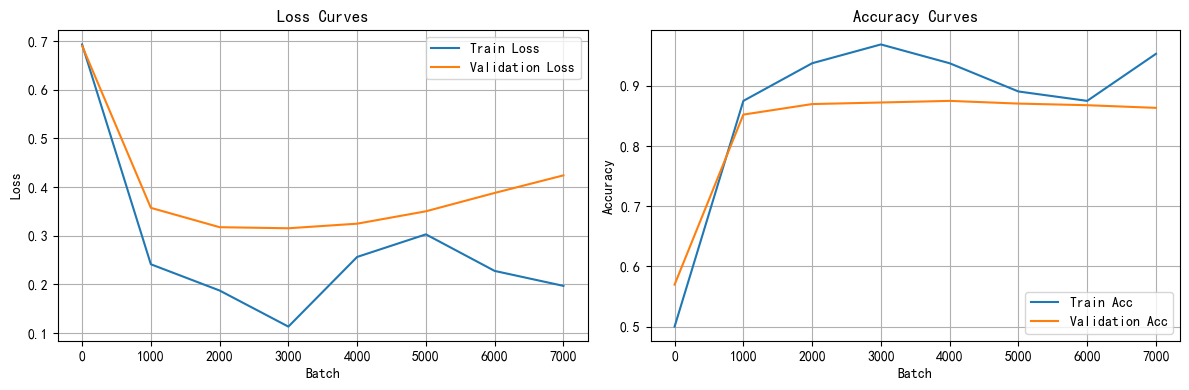

In [20]:
trainer.plot_curves()